## Question 1:

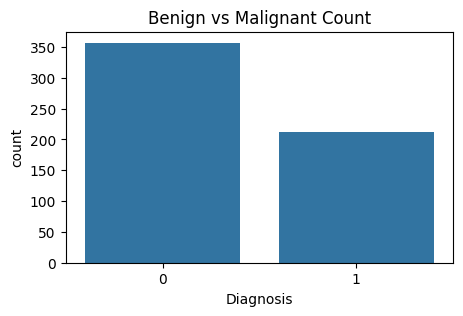


KNN Results:
Accuracy: 96.49
Sensitivity: 90.62
Specificity: 100.00
Precision: 100.00
G-Mean: 95.20
FDR: 0.00
FOR: 5.31
MCC: 0.93

SVM Results:
Accuracy: 95.91
Sensitivity: 89.06
Specificity: 100.00
Precision: 100.00
G-Mean: 94.37
FDR: 0.00
FOR: 6.14
MCC: 0.91


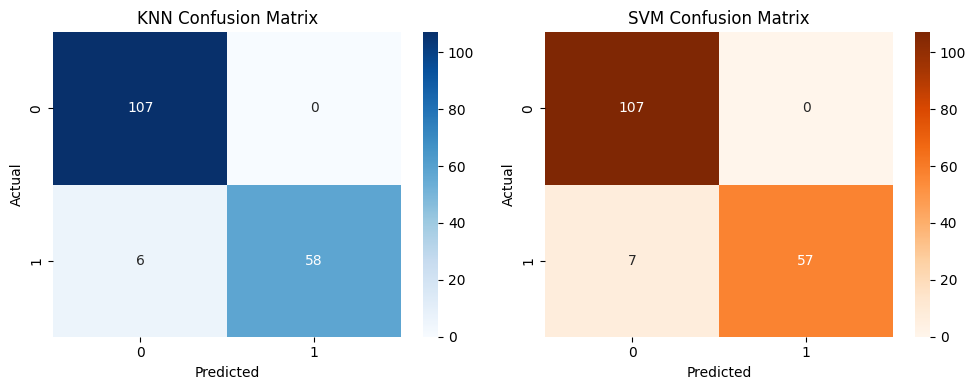

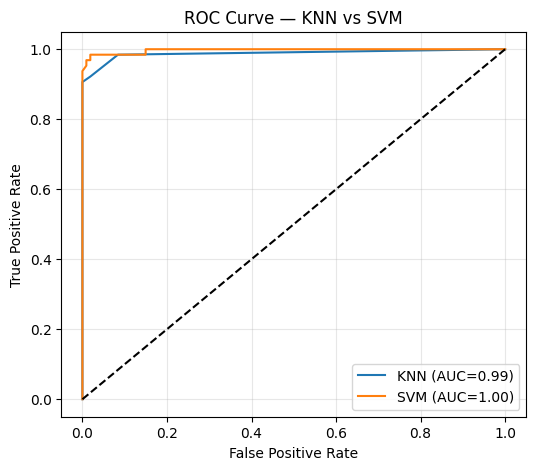

In [3]:
# Breast Cancer Wisconsin (Diagnostic) — KNN vs SVM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score,
    precision_score, matthews_corrcoef, roc_curve, auc
)

# dataset has no header so we add our own names
names = ["ID", "Diagnosis"] + [f"F{i}" for i in range(1, 31)]
df = pd.read_csv("wdbc.data", header=None, names=names)

# ID is useless for prediction
df = df.drop("ID", axis=1)

# convert M/B to 1/0
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

# EDA

plt.figure(figsize=(5,3))
sns.countplot(x=df["Diagnosis"])
plt.title("Benign vs Malignant Count")
plt.show()

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# scaling because SVM + KNN need it
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s = sc.transform(X_test)

# Train KNN and SVM

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

svm = SVC(probability=True)
svm.fit(X_train_s, y_train)

# Predictions

p_knn = knn.predict(X_test_s)
p_svm = svm.predict(X_test_s)

# Performance metrics

def get_scores(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_true, y_pred) * 100
    sens = recall_score(y_true, y_pred) * 100
    spec = (tn / (tn + fp)) * 100
    prec = precision_score(y_true, y_pred) * 100
    gmean = np.sqrt((sens/100) * (spec/100)) * 100
    fdr = (fp / (fp + tp)) * 100
    forr = (fn / (fn + tn)) * 100
    mcc = matthews_corrcoef(y_true, y_pred)

    return acc, sens, spec, prec, gmean, fdr, forr, mcc, cm

knn_scores = get_scores(y_test, p_knn)
svm_scores = get_scores(y_test, p_svm)

labels = ["Accuracy", "Sensitivity", "Specificity", "Precision",
          "G-Mean", "FDR", "FOR", "MCC"]

print("\nKNN Results:")
for name, val in zip(labels, knn_scores[:-1]):
    print(f"{name}: {val:.2f}")

print("\nSVM Results:")
for name, val in zip(labels, svm_scores[:-1]):
    print(f"{name}: {val:.2f}")

# Confusion Matrices (Fig 1)

cm_knn = knn_scores[-1]
cm_svm = svm_scores[-1]

fig, axs = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm_knn, annot=True, cmap="Blues", fmt="d", ax=axs[0])
axs[0].set_title("KNN Confusion Matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")

sns.heatmap(cm_svm, annot=True, cmap="Oranges", fmt="d", ax=axs[1])
axs[1].set_title("SVM Confusion Matrix")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ROC Curves (Fig 2)

knn_prob = knn.predict_proba(X_test_s)[:,1]
svm_prob = svm.predict_proba(X_test_s)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)

auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.2f})")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN vs SVM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Question 2:

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

df = pd.read_csv("wdbc.data", header=None)
columns = ["ID", "Diagnosis"] + [f"attr_{i}" for i in range(30)]
df.columns = columns
df.drop("ID", axis=1, inplace=True)
encoder = LabelEncoder()
df["Diagnosis"] = encoder.fit_transform(df["Diagnosis"])
X_data = df.drop("Diagnosis", axis=1)
y_data = df["Diagnosis"]

minmax_scaler = MinMaxScaler()
X_minmax_scaled = minmax_scaler.fit_transform(X_data)
std_scaler = StandardScaler()
X_standard_scaled = std_scaler.fit_transform(X_data)

def select_features(X, y, k=10):
    selector = SelectKBest(score_func=chi2, k=k)
    X_new = selector.fit_transform(X, y)
    selected_indices = selector.get_support(indices=True)
    return X_new, selected_indices

def calc_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
    sensitivity = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) * 100 if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0
    return accuracy, sensitivity, specificity, ppv, npv, cm

partitions = {"50-50": 0.5, "70-30": 0.3, "80-20": 0.2}
results_table = []
conf_matrices = {}

for name, test_size in partitions.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_minmax_scaled, y_data, test_size=test_size, random_state=42, stratify=y_data
    )
    X_train_sel, selected_indices = select_features(X_train, y_train, k=10)
    X_test_sel = X_test[:, selected_indices]
    clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
    clf.fit(X_train_sel, y_train)
    y_pred = clf.predict(X_test_sel)
    acc, sens, spec, ppv, npv, cm = calc_metrics(y_test, y_pred)
    results_table.append({
        "Partition": name,
        "Accuracy (%)": round(acc, 2),
        "Sensitivity (%)": round(sens, 2),
        "Specificity (%)": round(spec, 2),
        "PPV (%)": round(ppv, 2),
        "NPV (%)": round(npv, 2)
    })
    conf_matrices[name] = cm
    print(f"\n{name} Partition")
    print("Selected feature indices:", selected_indices)
    print("Confusion Matrix:\n", cm)

table6 = pd.DataFrame(results_table)
print("\nTABLE 6: Model Performance")
print(table6)

print("\nTABLE 7: Confusion Matrices")
for name, cm in conf_matrices.items():
    print(f"\n{name} partition confusion matrix:")
    print(pd.DataFrame(cm, index=["Actual Benign", "Actual Malignant"], columns=["Pred Benign", "Pred Malignant"]))



50-50 Partition
Selected feature indices: [ 0  2  3  6  7 20 22 23 26 27]
Confusion Matrix:
 [[177   2]
 [ 13  93]]

70-30 Partition
Selected feature indices: [ 0  2  3  6  7 20 22 23 26 27]
Confusion Matrix:
 [[107   0]
 [  8  56]]

80-20 Partition
Selected feature indices: [ 0  2  3  6  7 20 22 23 26 27]
Confusion Matrix:
 [[72  0]
 [ 5 37]]

TABLE 6: Model Performance
  Partition  Accuracy (%)  Sensitivity (%)  Specificity (%)  PPV (%)  NPV (%)
0     50-50         94.74            87.74            98.88    97.89    93.16
1     70-30         95.32            87.50           100.00   100.00    93.04
2     80-20         95.61            88.10           100.00   100.00    93.51

TABLE 7: Confusion Matrices

50-50 partition confusion matrix:
                  Pred Benign  Pred Malignant
Actual Benign             177               2
Actual Malignant           13              93

70-30 partition confusion matrix:
                  Pred Benign  Pred Malignant
Actual Benign             107 

## Question 3:

  Diagnosis  feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0         M      17.99      10.38     122.80     1001.0    0.11840    0.27760   
1         M      20.57      17.77     132.90     1326.0    0.08474    0.07864   
2         M      19.69      21.25     130.00     1203.0    0.10960    0.15990   
3         M      11.42      20.38      77.58      386.1    0.14250    0.28390   
4         M      20.29      14.34     135.10     1297.0    0.10030    0.13280   

   feature_6  feature_7  feature_8  ...  feature_20  feature_21  feature_22  \
0     0.3001    0.14710     0.2419  ...       25.38       17.33      184.60   
1     0.0869    0.07017     0.1812  ...       24.99       23.41      158.80   
2     0.1974    0.12790     0.2069  ...       23.57       25.53      152.50   
3     0.2414    0.10520     0.2597  ...       14.91       26.50       98.87   
4     0.1980    0.10430     0.1809  ...       22.54       16.67      152.20   

   feature_23  feature_24  feature_25 

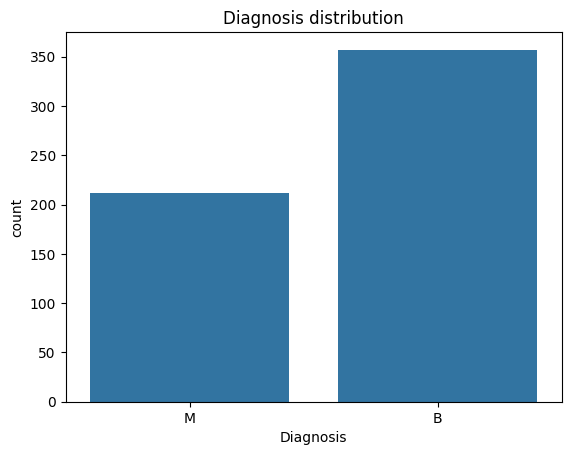


Class proportions:
 Diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64

SVM accuracy with default kernels:

linear kernel: 96.49%
poly kernel: 88.30%
rbf kernel: 96.49%
sigmoid kernel: 95.32%

SVM tuning results:

Kernel: linear
Best params: {'C': 0.1, 'gamma': 0.001}
Tuned Accuracy: 98.25%
Confusion Matrix:
 [[107   0]
 [  3  61]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       107
           1       1.00      0.95      0.98        64

    accuracy                           0.98       171
   macro avg       0.99      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171

--------------------------------------------------
Kernel: poly
Best params: {'C': 1, 'gamma': 0.1}
Tuned Accuracy: 93.57%
Confusion Matrix:
 [[107   0]
 [ 11  53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv("wdbc.data", header=None)
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(30)]
df.columns = columns
df.drop("ID", axis=1, inplace=True)

print(df.head())
print("\nShape:", df.shape)
print("\nInfo:\n", df.info())
print("\nStats:\n", df.describe())

print("\nMissing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

sns.countplot(data=df, x="Diagnosis")
plt.title("Diagnosis distribution")
plt.show()
print("\nClass proportions:\n", df["Diagnosis"].value_counts(normalize=True))

# Encode target
df["Diagnosis"] = LabelEncoder().fit_transform(df["Diagnosis"])
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

kernels = ["linear", "poly", "rbf", "sigmoid"]
print("\nSVM accuracy with default kernels:\n")
for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{k} kernel: {acc*100:.2f}%")

params = {"C": [0.1, 1, 10, 100], "gamma": [0.001, 0.01, 0.1, 1]}
print("\nSVM tuning results:\n")
for k in kernels:
    print(f"Kernel: {k}")
    svc = SVC(kernel=k, random_state=42)
    grid = GridSearchCV(svc, params, cv=5, scoring="accuracy", verbose=0)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    tuned_pred = best.predict(X_test)
    tuned_acc = accuracy_score(y_test, tuned_pred)
    print("Best params:", grid.best_params_)
    print(f"Tuned Accuracy: {tuned_acc*100:.2f}%")
    print("Confusion Matrix:\n", confusion_matrix(y_test, tuned_pred))
    print("Classification Report:\n", classification_report(y_test, tuned_pred))
    print("-"*50)
